In [3]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")


## Data Preparation
Create a signal (gaussian) and background (exponential) sample.
Yields are similar to the leading category of ggF analysis

In [96]:

size_bkg = 220_000_00
f_truth = 0.848
tau1=1/0.009
tau2=1/0.04
true_params = [f_truth, tau1, tau2]

def sample_twoExp(size, f, tau1, tau2):
    # Choose component for each event: True → tau1, False → tau2
    choose = np.random.rand(size) < f
    
    # Allocate result array
    x = np.empty(size)
    
    # Exponential sampling: x = -tau * log(U)
    x[choose]  = -tau1 * np.log(np.random.rand(np.sum(choose)))
    x[~choose] = -tau2 * np.log(np.random.rand(np.sum(~choose)))
    
    return x
N      = 200_000_0  # this is just the total number of events you want
f      = 0.848
tau1   = 1/0.009
tau2   = 1/0.04

bkg = sample_twoExp(N, f, tau1, tau2)
sig = np.random.normal(loc=125, scale=14,size=200)

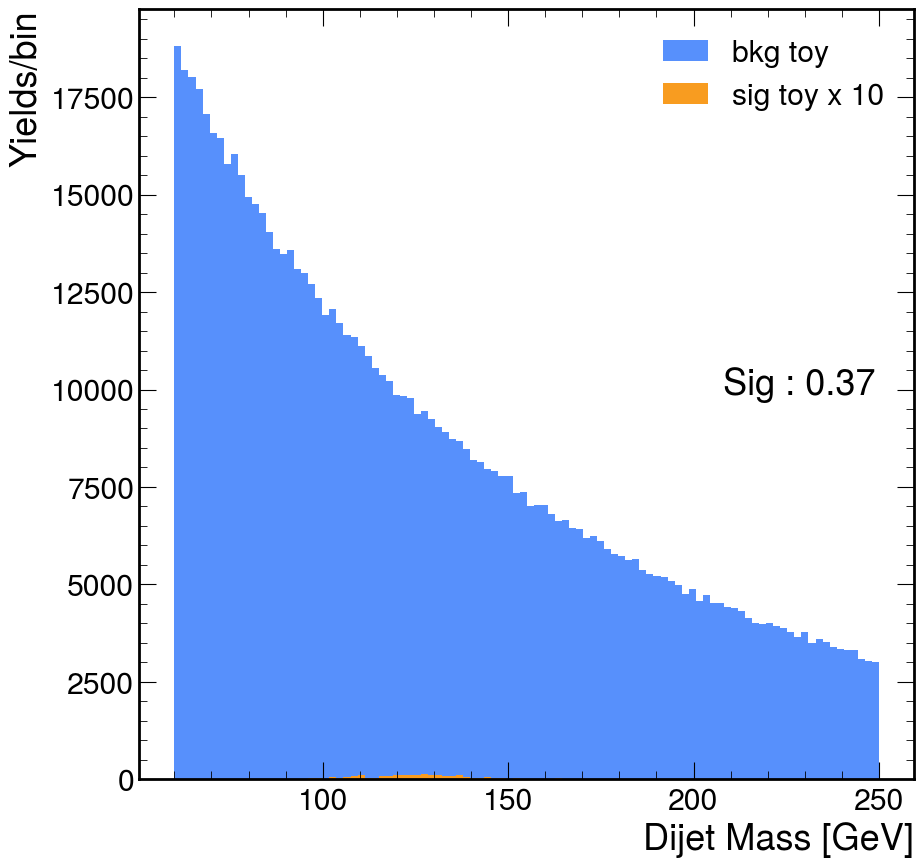

In [97]:

bins=np.linspace(60, 250, 101)
fig, ax = plt.subplots(1, 1)
ax.hist(bkg,  bins=bins, label='bkg toy')
ax.hist(sig,  bins=bins, label='sig toy x 10', weights=np.ones(len(sig))*10)
significance = np.sum(((sig>100) & (sig<150))) / np.sqrt(np.sum(((bkg>100) & (bkg<150))))
ax.text(x=0.95, y=0.5, s="Sig : %.2f"%significance, transform=ax.transAxes, ha='right')
ax.set_xlabel("Dijet Mass [GeV]")
ax.set_ylabel("Yields/bin")
ax.legend()


In [98]:
df = np.concatenate([bkg, sig])

Exponential fit:
<ValueView N=3915970.348600036 f=0.8329941917913669 tau1=109.41185156444081 tau2=21.029807055275505>


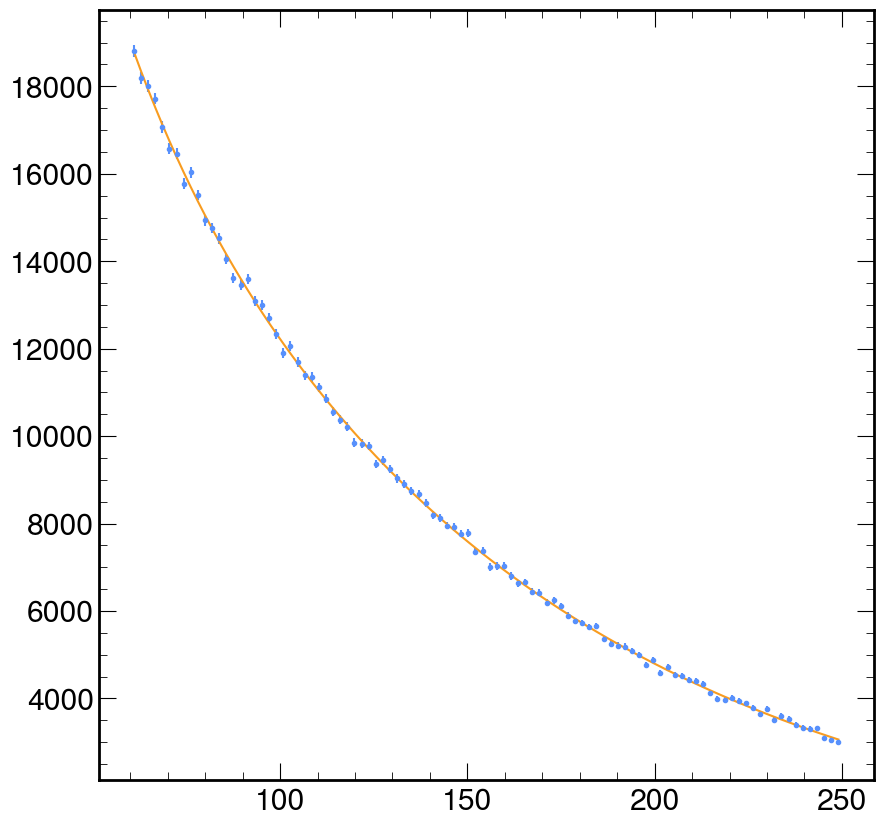

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 122.4                      │              Nfcn = 369              │
│ EDM = 1.97e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N    │  3.92e6   │  0.16e6   │            │            │         │         │       │
│ 1 │ f    │   0.833   │   0.029   │            │            │ 0.7632  │ 0.9328  │       │
│ 2 │ tau1 │   109.4   │    0.8    │            │            │ 77.7778 │ 122.222 │       │
│ 3 │ tau2 │   21.0    │    2.7    │            │            │  17.5   │  27.5   │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬─────────────────────────────────────────────────────┐
│      │            N            f         tau1         tau2 │
├──────┼─────────────────────────────────────────────────────┤
│    N │     2.53e+10 -4.7248832e3   -92.6243e3   -452.411e3 │
│    f │ -4.7248832e3      0.00089      15.8e-3      82.5e-3 │
│ tau1 │   -92.6243e3      15.8e-3        0.648          2.0 │
│ tau2 │   -452.411e3      82.5e-3          2.0         8.53 │
└──────┴─────────────────────────────────────────────────────┘

In [99]:
import numpy as np
from iminuit import Minuit
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# 1) Exponential fit: f(x) = norm * exp(-x / tau)  with tau fixed = 100
# -----------------------------------------------------------
x=(bins[1:]+bins[:-1])/2
y_bkg=np.histogram(bkg, bins=bins)[0]
yerr=np.sqrt(y_bkg)


def twoExp(x, N, f, tau1, tau2):
    return N * ( f * (1/tau1) * np.exp(-x/tau1)
               + (1-f) * (1/tau2) * np.exp(-x/tau2) )
def chi2(N, f, tau1, tau2):
    model = twoExp(x, N, f, tau1, tau2)
    return np.sum(((y_bkg - model) / yerr)**2)
m1 = Minuit(
    chi2,
    N=380802.571615352,
    f=f_truth,
    tau1=tau1,
    tau2=tau2,
)
m1.limits["f"]=[f_truth*0.9,f_truth*1.1]
m1.limits["tau1"]=[0.7*tau1,1.1*tau1]
m1.limits["tau2"]=[0.7*tau2,1.1*tau2]
m1.errordef = Minuit.LEAST_SQUARES
m1.migrad()
m1.hesse()

print("Exponential fit:")
print(m1.values)

# Plot
fig, ax = plt.subplots(1, 1)
ax.errorbar(x, y_bkg, yerr=yerr, fmt='.')
ax.plot(x, twoExp(x, **dict(zip(m1.parameters, m1.values))))

plt.show()
m1

Text(0, 1, 'Pulls')

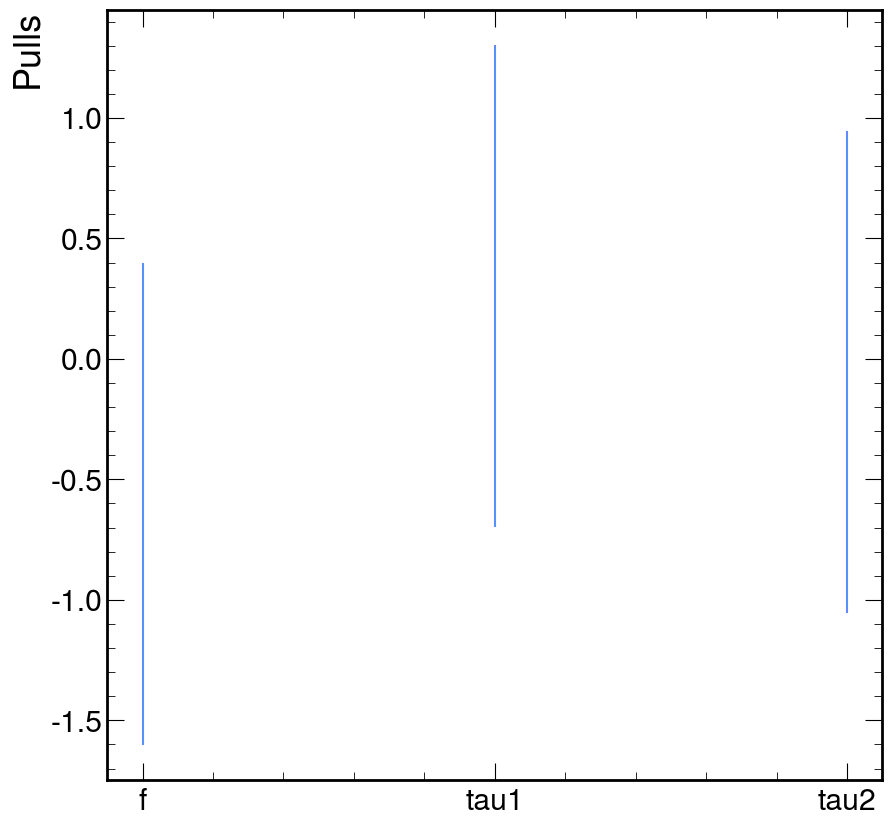

In [8]:
fig, ax = plt.subplots(1, 1)
idx   = np.arange(len(m1.values[1:]))
pulls = (m1.values[1:] - np.array(true_params)) / m1.errors[1:]
ax.errorbar(idx, pulls, 1, linestyle="none")

ax.set_xticks(idx)
ax.set_xticklabels(list(m1.parameters[1:]))
ax.set_ylabel("Pulls")


In [100]:
pars_err_Bonly = {
    "f": ([], []),
    "tau1": ([], []),
    "tau2": ([], [])
}
for i in range(500):
    bkg_Bonly = sample_twoExp(N, f, tau1, tau2)
    y_bkg_Bonly=np.histogram(bkg_Bonly, bins=bins)[0]
    yerr=np.sqrt(y_bkg_Bonly)
    m1 = Minuit(chi2,
                N=380802.571615352,
                f=f_truth,
                tau1=tau1,
                tau2=tau2,
    )
    m1.limits["f"]=[0.5,1]
    m1.limits["tau1"]=[0.5*tau1,2*tau1]
    m1.limits["tau2"]=[0.5*tau2,2*tau2]
    m1.errordef = Minuit.LEAST_SQUARES
    m1.migrad()
#    if not m1.valid:
#        continue
    m1.hesse() 
    
    pars_err_Bonly["f"][0].append(m1.values["f"])
    pars_err_Bonly["f"][1].append(m1.errors["f"])
    
    pars_err_Bonly["tau1"][0].append(m1.values["tau1"])
    pars_err_Bonly["tau1"][1].append(m1.errors["tau1"])
    
    pars_err_Bonly["tau2"][0].append(m1.values["tau2"])
    pars_err_Bonly["tau2"][1].append(m1.errors["tau2"])
    


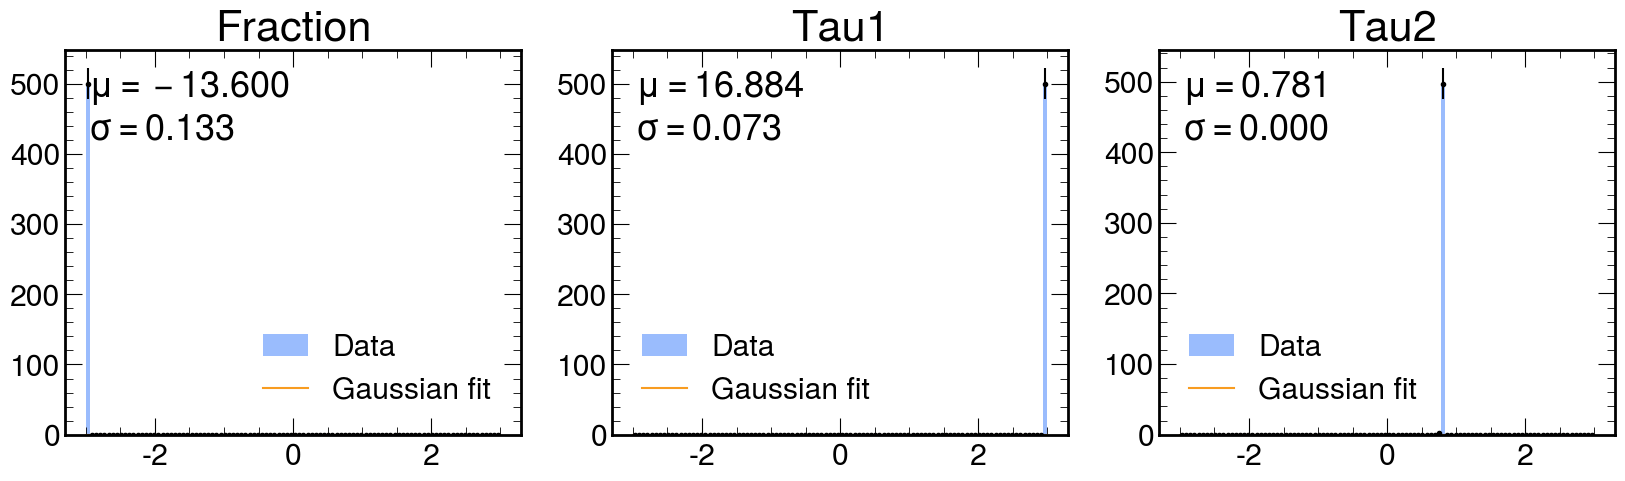

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_with_gaussian(data, bins, title=None, color=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    else:
        pass

    # Istogramma + errori poissoniani
    counts, edges, _ = ax.hist(np.clip(data, bins[0], bins[-1]), bins=bins, alpha=0.6, label="Data", color=color)
    centers = 0.5 * (edges[:-1] + edges[1:])
    errors = np.sqrt(counts)

    ax.errorbar(centers, counts, yerr=errors, fmt='.', color='black')

    # Fit gaussiano
    mu, sigma = norm.fit(data)

    xfit = np.linspace(edges[0], edges[-1], 400)
    yfit = norm.pdf(xfit, mu, sigma) * np.sum(counts) * (edges[1] - edges[0])
    ax.plot(xfit, yfit, label="Gaussian fit")

    # Annotazione parametri
    ax.text(
        0.05, 0.95,
        f"$\\mu = {mu:.3f}$\n$\\sigma = {sigma:.3f}$",
        transform=ax.transAxes,
        ha="left", va="top"
    )

    if title:
        ax.set_title(title)

    ax.legend()
    if ax is None:
        return fig, ax
    else:
        return ax


# --- PRIMO ---
fig, ax = plt.subplots(1, 3, figsize=(20,5))
data1 = (np.array(pars_err_Bonly["f"][0]) - f) / np.array(pars_err_Bonly["f"][1])
ax[0] = plot_with_gaussian(data1, bins=np.linspace(-3, 3, 101), title="Fraction", ax=ax[0])

#plot_with_gaussian(data1, bins=np.linspace(-3, 3, 21), title="Tau2")

# --- SECONDO ---
data2 = (np.array(pars_err_Bonly["tau1"][0]) - tau1) / np.array(pars_err_Bonly["tau1"][1])
ax[1]=plot_with_gaussian(data2, bins=np.linspace(-3, 3, 101), title="Tau1", ax=ax[1])
#plot_with_gaussian(data2, bins=np.linspace(-3, 3, 21), title="Tau1")

# --- TERZO ---
data3 = (np.array(pars_err_Bonly["tau2"][0]) - tau2) / np.array(pars_err_Bonly["tau2"][1])
ax[2]=plot_with_gaussian(data3, bins=np.linspace(-3, 3, 101), title="Tau2", ax=ax[2])
#plot_with_gaussian(data3, bins=np.linspace(-5, 5, 41), title="Fraction")




# Bias when fitting S+B

Now fit the full distribution and you should see that parameters will not be well estimated in the S+B distributions

In [56]:
pars_err_SB = {
    m1.parameters[1] : ([],[]),
    m1.parameters[2] : ([],[]),
    m1.parameters[3] : ([],[])
}
for i in range(1000):
    bkg = sample_twoExp(N, f, tau1, tau2)
    sig = np.random.normal(loc=125, scale=14,size=100)
    bkg = np.concatenate([bkg,sig])
    y_bkg=np.histogram(bkg, bins=bins)[0]
    yerr=np.sqrt(y_bkg)
    m1 = Minuit(chi2,
                N=380802.571615352,
                f=f_truth,
                tau1=tau1,
                tau2=tau2,
    )
    m1.limits["f"]=[f_truth*0.7,f_truth*1.3]
    m1.limits["tau1"]=[0.7*tau1,1.5*tau1]
    m1.limits["tau2"]=[0.7*tau2,3*tau2]
    m1.errordef = Minuit.LEAST_SQUARES
    m1.migrad()
    m1.hesse()
    
    pars_err_SB[m1.parameters[1]][0].append(m1.values[1])
    pars_err_SB[m1.parameters[1]][1].append(m1.errors[1])

    pars_err_SB[m1.parameters[2]][0].append(m1.values[2])
    pars_err_SB[m1.parameters[2]][1].append(m1.errors[2])

    pars_err_SB[m1.parameters[3]][0].append(m1.values[3])
    pars_err_SB[m1.parameters[3]][1].append(m1.errors[3])
    


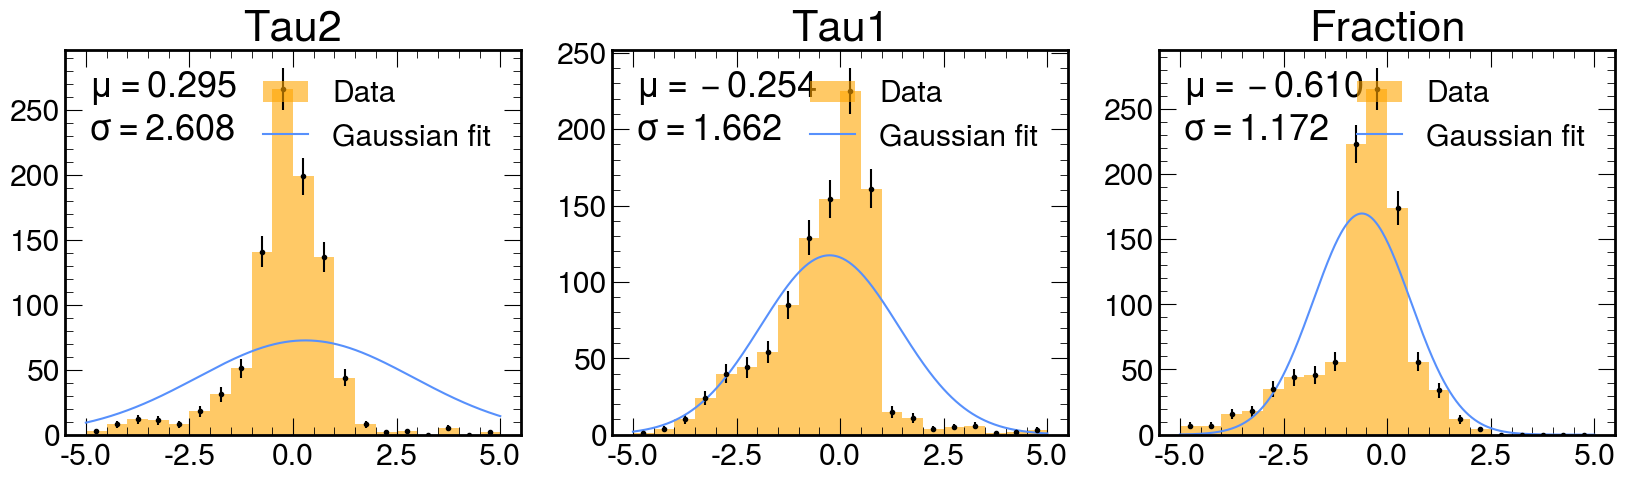

In [57]:
fig, ax = plt.subplots(1, 3, figsize=(20,5))
# --- PRIMO ---
data1 = (np.array(pars_err_SB[m1.parameters[3]][0]) - tau2) / np.array(pars_err_SB[m1.parameters[3]][1])
ax[0]=plot_with_gaussian(data1, bins=np.linspace(-5, 5, 21), title="Tau2", color='orange', ax=ax[0])

# --- SECONDO ---
data2 = (np.array(pars_err_SB[m1.parameters[2]][0]) - tau1) / np.array(pars_err_SB[m1.parameters[2]][1])
ax[1]=plot_with_gaussian(data2, bins=np.linspace(-5, 5, 21), title="Tau1", color='orange',ax=ax[1])

# --- TERZO ---
data3 = (np.array(pars_err_SB[m1.parameters[1]][0]) - f_truth) / np.array(pars_err_SB[m1.parameters[1]][1])
ax[2]=plot_with_gaussian(data3, bins=np.linspace(-5, 5, 21), title="Fraction", color='orange', ax=ax[2])



## Bias when fitting S+B with small Stat

In [58]:
pars_err_SB_smallStat = {
    m1.parameters[1] : ([],[]),
    m1.parameters[2] : ([],[]),
    m1.parameters[3] : ([],[])
}
for i in range(100):
    bkg = sample_twoExp(N//10, f, tau1, tau2)
    sig = np.random.normal(loc=125, scale=14,size=100//10)
    bkg = np.concatenate([bkg,sig])
    y_bkg=np.histogram(bkg, bins=bins)[0]
    yerr=np.sqrt(y_bkg)
    m1 = Minuit(chi2,
                N=380802.571615352,
                f=f_truth,
                tau1=tau1,
                tau2=tau2,
    )
    m1.limits["f"]=[f_truth*0.7,f_truth*1.3]
    m1.limits["tau1"]=[0.7*tau1,1.5*tau1]
    m1.limits["tau2"]=[0.7*tau2,3*tau2]
    m1.errordef = Minuit.LEAST_SQUARES
    m1.migrad()
    m1.hesse()
    
    pars_err_SB_smallStat[m1.parameters[1]][0].append(m1.values[1])
    pars_err_SB_smallStat[m1.parameters[1]][1].append(m1.errors[1])

    pars_err_SB_smallStat[m1.parameters[2]][0].append(m1.values[2])
    pars_err_SB_smallStat[m1.parameters[2]][1].append(m1.errors[2])

    pars_err_SB_smallStat[m1.parameters[3]][0].append(m1.values[3])
    pars_err_SB_smallStat[m1.parameters[3]][1].append(m1.errors[3])
    


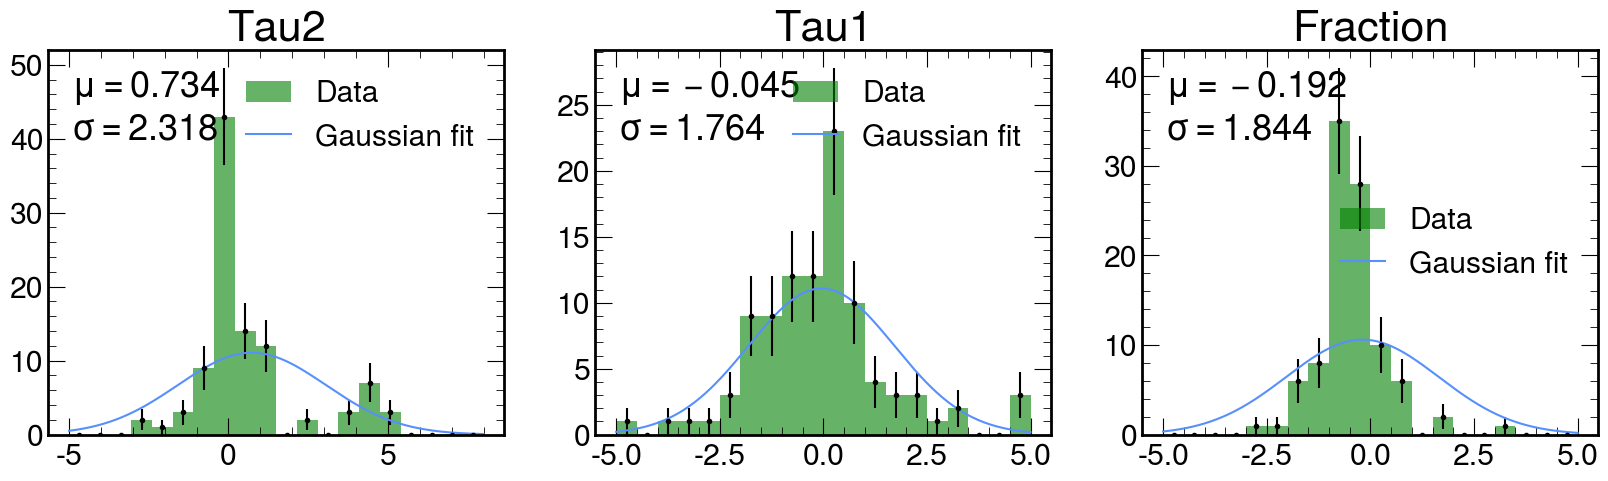

In [59]:
fig, ax = plt.subplots(1, 3, figsize=(20,5))
# --- PRIMO ---
data1 = (np.array(pars_err_SB_smallStat[m1.parameters[3]][0]) - tau2) / np.array(pars_err_SB_smallStat[m1.parameters[3]][1])
ax[0]=plot_with_gaussian(data1, bins=np.linspace(-5, 8, 21), title="Tau2", color='green', ax=ax[0])

# --- SECONDO ---
data2 = (np.array(pars_err_SB_smallStat[m1.parameters[2]][0]) - tau1) / np.array(pars_err_SB_smallStat[m1.parameters[2]][1])
ax[1]=plot_with_gaussian(data2, bins=np.linspace(-5, 5, 21), title="Tau1", color='green', ax=ax[1])

# --- TERZO ---
data3 = (np.array(pars_err_SB_smallStat[m1.parameters[1]][0]) - f_truth) / np.array(pars_err_SB_smallStat[m1.parameters[1]][1])
ax[2]=plot_with_gaussian(data3, bins=np.linspace(-5, 5, 21), title="Fraction", color='green', ax=ax[2])

plt.show()


## Bias when fitting B only at small stat

In [60]:
pars_err_SB_smallStat = {
    m1.parameters[1] : ([],[]),
    m1.parameters[2] : ([],[]),
    m1.parameters[3] : ([],[])
}
for i in range(1000):
    bkg = sample_twoExp(N//10, f, tau1, tau2)
    y_bkg=np.histogram(bkg, bins=bins)[0]
    yerr=np.sqrt(y_bkg)
    m1 = Minuit(chi2,
                N=380802.571615352,
                f=f_truth,
                tau1=tau1,
                tau2=tau2,
    )
    m1.limits["f"]=[f_truth*0.7,f_truth*1.3]
    m1.limits["tau1"]=[0.7*tau1,1.5*tau1]
    m1.limits["tau2"]=[0.7*tau2,3*tau2]
    m1.errordef = Minuit.LEAST_SQUARES
    m1.migrad()
    m1.hesse()
    
    pars_err_SB_smallStat[m1.parameters[1]][0].append(m1.values[1])
    pars_err_SB_smallStat[m1.parameters[1]][1].append(m1.errors[1])

    pars_err_SB_smallStat[m1.parameters[2]][0].append(m1.values[2])
    pars_err_SB_smallStat[m1.parameters[2]][1].append(m1.errors[2])

    pars_err_SB_smallStat[m1.parameters[3]][0].append(m1.values[3])
    pars_err_SB_smallStat[m1.parameters[3]][1].append(m1.errors[3])
    


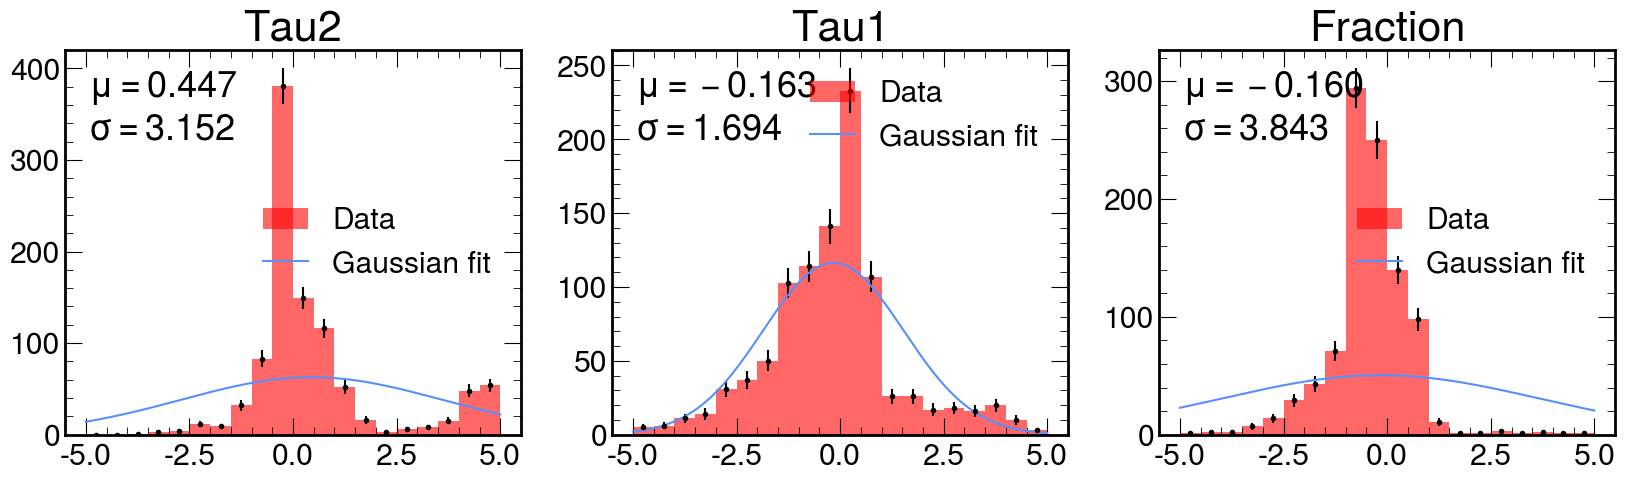

In [61]:
fig, ax = plt.subplots(1, 3, figsize=(20,5))
# --- PRIMO ---
data1 = (np.array(pars_err_SB_smallStat[m1.parameters[3]][0]) - tau2) / np.array(pars_err_SB_smallStat[m1.parameters[3]][1])
ax[0]=plot_with_gaussian(data1, bins=np.linspace(-5, 5, 21), title="Tau2", color='red',ax=ax[0])

# --- SECONDO ---
data2 = (np.array(pars_err_SB_smallStat[m1.parameters[2]][0]) - tau1) / np.array(pars_err_SB_smallStat[m1.parameters[2]][1])
ax[1]=plot_with_gaussian(data2, bins=np.linspace(-5, 5, 21), title="Tau1", color='red',ax=ax[1])

# --- TERZO ---
data3 = (np.array(pars_err_SB_smallStat[m1.parameters[1]][0]) - f_truth) / np.array(pars_err_SB_smallStat[m1.parameters[1]][1])
ax[2]=plot_with_gaussian(data3, bins=np.linspace(-5, 5, 21), title="Fraction", color='red',ax=ax[2])

plt.show()


## One can prove that at low stat fitting S or S+B is insiginificant.
For which S/b this is true?

In [94]:
tau2

25.0

In [95]:
1/0.04

25.0